# Hypothesis 1 — Are the mysterious spectral features artifacts of high-pass filtering?

**Features under investigation** (retrieval 628541 as reference example):
- Marginal emission near **2154 nm**
- Deep absorption near **2149 nm**
- Emission feature near **2176 nm**
- Some absorption lines appear shallower in the retrieved model than in the data

**Hypothesis**: The features are artifacts introduced by the per-chip Savitzky-Golay (or Gaussian HP) normalization used in the validation/plotting pipeline, which removes the continuum shape and can create false emission/absorption bumps.

**Setup for retrieval 628541** (v5.0_piette_RM, Guidebook v2.0):
- Data: **flux-calibrated** (`extracted_spectra_combined_flux_cal.npy`), in W/m²/μm
- Model: pRT surface flux × **(R/d)²**, also in W/m²/μm — `log_R` is a free parameter
- Normalization: **None** — absolute flux preserved
- Scaling: **No phi** (`PerChipScaleFalse`); model and data are on the same absolute scale by construction

**Correct test**: Load flux-calibrated data and saved model flux and plot them **directly on the same axis — no normalization at all**. Then repeat with binning to reduce noise.

If the features disappear in the raw (absolute) comparison, Hypothesis 1 is confirmed.

## 0. Configuration

In [4]:
from pathlib import Path

# ── change these to switch retrieval ──────────────────────────────────────────
RETRIEVAL_SERIES = '628541'
RETRIEVAL_DIR = Path(f'/data2/peng/retrievals/{RETRIEVAL_SERIES}_N800_ev0.5_NormNone_PerChipScaleFalse')

WORKPATH     = Path('/data2/peng')
COMBINED_DIR = WORKPATH / 'combined_two_nights'

# Barycentric correction for Night 1 (used to align model wavelengths to the
# barycentric frame of the combined data; from PyAstronomy helcorr / recording_recipe.md)
VCORR_N1_KMS = -15.37101   # km/s  (Earth toward DH Tau, Night 1)

# Feature wavelengths to zoom into (nm, barycentric frame)
FEATURES = {
    'absorption ~2149 nm': (2142, 2157),
    'emission ~2154 nm':   (2142, 2162),
    'emission ~2176 nm':   (2168, 2185),
}

print('Retrieval dir    :', RETRIEVAL_DIR)
print('Combined data dir:', COMBINED_DIR)
print('Exists:', RETRIEVAL_DIR.exists(), '/', COMBINED_DIR.exists())


Retrieval dir    : /data2/peng/retrievals/628541_N800_ev0.5_NormNone_PerChipScaleFalse
Combined data dir: /data2/peng/combined_two_nights
Exists: True / True


## 1. Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

## 2. Load combined two-night flux-calibrated data and saved model

Both are in W/m²/μm.  The combined file was produced by
`cooking_combine_spectra_inter_night.ipynb` (Step 8) using LPU co-addition on the
**night-1 barycentric wavelength grid**.  The retrieval model is saved on the
**night-1 topocentric grid**; we apply the barycentric correction (VCORR_N1) to the
model wavelengths so both spectra are in the same barycentric frame.

In [6]:
import numpy as np
from astropy.io import fits

# Load combined two-night flux-calibrated spectrum
# Shape (3, 5, 2048) on the night-1 barycentric wavelength grid
spec_raw  = np.load(COMBINED_DIR / 'extracted_spectra_combined_two_nights_flux_cal.npy')
err_raw   = np.load(COMBINED_DIR / 'extracted_spectra_combined_two_nights_flux_cal_err.npy')
wave_raw  = np.load(COMBINED_DIR / 'WLEN_combined_two_nights_bary.npy')  # (3, 5, 2048) nm, bary

print(f'Combined data  : {spec_raw.shape}, median = {np.nanmedian(spec_raw):.3e} W/m²/μm')
print(f'Wavelength grid: {wave_raw.shape}, range {wave_raw[wave_raw>0].min():.1f}–{wave_raw.max():.1f} nm (bary)')

# Flatten to 1-D, mask zeros / NaNs, sort by wavelength
spec_flat = spec_raw.reshape(-1)
err_flat  = err_raw.reshape(-1)
wave_flat = wave_raw.reshape(-1)

spec_flat = np.where(spec_flat == 0, np.nan, spec_flat)
err_flat  = np.where(err_flat  == 0, np.nan, err_flat)
valid = np.isfinite(spec_flat) & np.isfinite(err_flat) & np.isfinite(wave_flat)

sort_idx = np.argsort(wave_flat[valid])
wave_d = wave_flat[valid][sort_idx]   # nm, barycentric
flux_d = spec_flat[valid][sort_idx]   # W/m²/μm
err_d  = err_flat[valid][sort_idx]

# Chip boundaries from the 3-D wave array (for vertical grid lines)
chip_bounds = [(wave_raw[d, o].min(), wave_raw[d, o].max())
               for o in range(5) for d in range(3)]

print(f'Valid pixels   : {len(wave_d)} / {valid.size}')
print(f'Wave range     : {wave_d.min():.1f}–{wave_d.max():.1f} nm')


Combined data  : (3, 5, 2048), median = 9.951e-16 W/m²/μm
Wavelength grid: (3, 5, 2048), range 2063.6–2472.2 nm (bary)
Valid pixels   : 24964 / 30720
Wave range     : 2063.8–2470.6 nm


In [7]:
# Load saved model flux (on the night-1 TOPOCENTRIC wavelength grid)
wave_m_topo = np.load(RETRIEVAL_DIR / 'retrieval_model_wave.npy')
flux_m_raw  = np.load(RETRIEVAL_DIR / 'retrieval_model_flux_scaled.npy')
flux_m_raw  = np.where(np.isinf(flux_m_raw), np.nan, flux_m_raw)

# Shift model wavelengths from topocentric → barycentric frame so they align
# with the combined data (which is on the night-1 barycentric grid).
# λ_bary = λ_topo × (1 + VCORR/c);  VCORR = −15.37 km/s → small blueward shift.
from astropy import constants as const
c_kms = const.c.to('km/s').value
wave_m_bary = wave_m_topo * (1.0 + VCORR_N1_KMS / c_kms)

sort_m = np.argsort(wave_m_bary)
wave_m = wave_m_bary[sort_m]
flux_m = flux_m_raw[sort_m]
valid_m = np.isfinite(flux_m) & np.isfinite(wave_m)

print(f'Model (bary-shifted): {valid_m.sum()} valid pixels, '
      f'median = {np.nanmedian(flux_m[valid_m]):.3e} W/m²/μm')
print(f'Bary shift applied  : Δλ/λ = {VCORR_N1_KMS/c_kms:.2e}  '
      f'(≈ {VCORR_N1_KMS/c_kms*2150:.3f} nm at 2150 nm)')
print()
print(f'Scale check — data/model median ratio: '
      f'{np.nanmedian(flux_d) / np.nanmedian(flux_m[valid_m]):.4f}')
print('(should be ~1.0 for a well-scaled absolute comparison)')


Model (bary-shifted): 24950 valid pixels, median = 9.961e-16 W/m²/μm
Bary shift applied  : Δλ/λ = -5.13e-05  (≈ -0.110 nm at 2150 nm)

Scale check — data/model median ratio: 0.9990
(should be ~1.0 for a well-scaled absolute comparison)


## 3. Helper: block binning

In [8]:
def block_bin(wave, flux, err=None, bin_size=5):
    """Average flux in non-overlapping blocks of `bin_size` pixels."""
    n = len(wave)
    n_bins = n // bin_size
    w_bin = np.full(n_bins, np.nan)
    f_bin = np.full(n_bins, np.nan)
    e_bin = np.full(n_bins, np.nan)

    for i in range(n_bins):
        sl = slice(i * bin_size, (i + 1) * bin_size)
        f_sl = flux[sl]
        ok = np.isfinite(f_sl)
        if ok.sum() == 0:
            continue
        w_bin[i] = np.mean(wave[sl][ok])
        f_bin[i] = np.mean(f_sl[ok])
        if err is not None:
            e_sl = err[sl]
            e_bin[i] = np.sqrt(np.nansum(e_sl[ok]**2)) / ok.sum()
        else:
            e_bin[i] = np.std(f_sl[ok]) / np.sqrt(ok.sum())

    ok = np.isfinite(f_bin)
    return w_bin[ok], f_bin[ok], e_bin[ok]


# Bin sizes: 5 px (~3 resolution elements at R≈100k, ≈0.1 nm) and 20 px (~0.25 nm)
BIN_SMALL = 5
BIN_LARGE = 20

wb5_d,  fb5_d,  eb5_d  = block_bin(wave_d, flux_d, err_d, bin_size=BIN_SMALL)
wb5_m,  fb5_m,  _      = block_bin(wave_m[valid_m], flux_m[valid_m], bin_size=BIN_SMALL)
wb20_d, fb20_d, eb20_d = block_bin(wave_d, flux_d, err_d, bin_size=BIN_LARGE)
wb20_m, fb20_m, _      = block_bin(wave_m[valid_m], flux_m[valid_m], bin_size=BIN_LARGE)

print(f'Bin-5  : {len(wb5_d)} data bins,  {len(wb5_m)} model bins')
print(f'Bin-20 : {len(wb20_d)} data bins,  {len(wb20_m)} model bins')

Bin-5  : 4992 data bins,  4990 model bins
Bin-20 : 1248 data bins,  1247 model bins


## 4. Full-spectrum comparison — absolute flux, no normalization

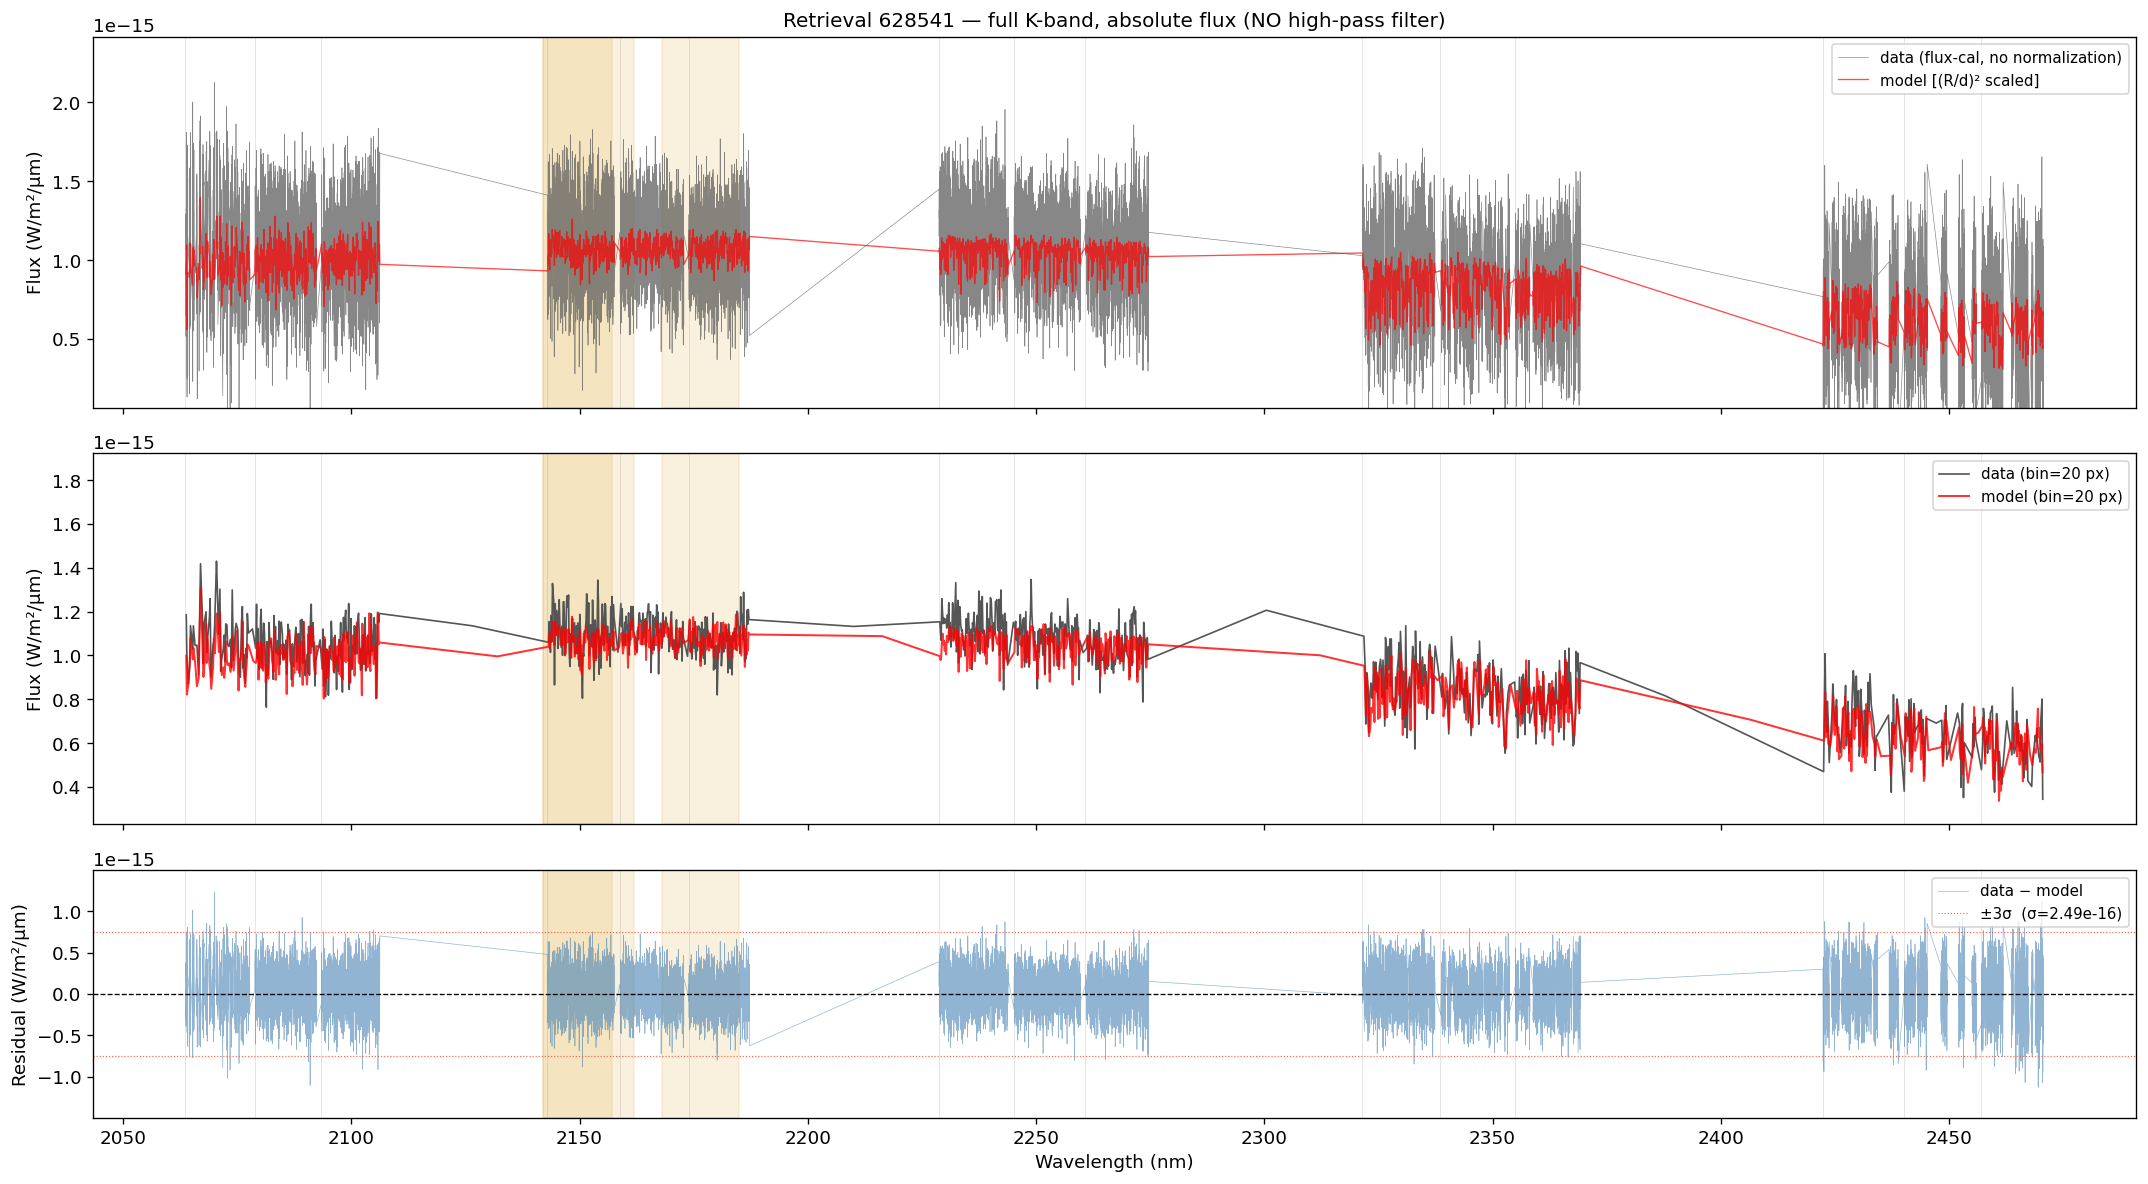

In [9]:
# Interpolate model onto data wavelength grid for residuals
flux_m_interp = np.interp(wave_d, wave_m[valid_m], flux_m[valid_m])
residuals_raw = flux_d - flux_m_interp

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 3, 2]})

# Panel 1 — unbinned, absolute flux
ax = axes[0]
ax.plot(wave_d, flux_d, color='#555', lw=0.4, alpha=0.7, label='data (flux-cal, no normalization)')
ax.plot(wave_m[valid_m], flux_m[valid_m], color='red', lw=0.8, alpha=0.7, label='model [(R/d)² scaled]')
ax.set_ylabel('Flux (W/m²/μm)')
ax.set_title(f'Retrieval {RETRIEVAL_SERIES} — full K-band, absolute flux (NO high-pass filter)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(np.nanpercentile(flux_d, 1) * 0.5, np.nanpercentile(flux_d, 99) * 1.5)
for label, (w0, w1) in FEATURES.items():
    ax.axvspan(w0, w1, alpha=0.15, color='goldenrod')

# Panel 2 — bin-20, absolute flux
ax = axes[1]
ax.plot(wb20_d, fb20_d, color='#555', lw=1.0, label=f'data (bin={BIN_LARGE} px)')
ax.plot(wb20_m, fb20_m, color='red', lw=1.2, alpha=0.8, label=f'model (bin={BIN_LARGE} px)')
ax.set_ylabel('Flux (W/m²/μm)')
ax.set_ylim(np.nanpercentile(fb20_d, 1) * 0.5, np.nanpercentile(fb20_d, 99) * 1.5)
ax.legend(loc='upper right', fontsize=9)
for label, (w0, w1) in FEATURES.items():
    ax.axvspan(w0, w1, alpha=0.15, color='goldenrod')

# Panel 3 — residuals (unbinned)
ax = axes[2]
ax.plot(wave_d, residuals_raw, color='steelblue', lw=0.4, alpha=0.6, label='data − model')
ax.axhline(0, color='k', lw=0.8, ls='--')
sig = np.nanstd(residuals_raw)
ax.axhline( 3*sig, color='tomato', lw=0.7, ls=':', label=f'±3σ  (σ={sig:.2e})')
ax.axhline(-3*sig, color='tomato', lw=0.7, ls=':')
ax.set_ylabel('Residual (W/m²/μm)')
ax.set_xlabel('Wavelength (nm)')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-6*sig, 6*sig)
for label, (w0, w1) in FEATURES.items():
    ax.axvspan(w0, w1, alpha=0.15, color='goldenrod')

# Chip boundaries
for lo, hi in chip_bounds:
    for ax_ in axes:
        ax_.axvline(lo, color='gray', lw=0.3, alpha=0.4)

plt.tight_layout()
plt.savefig(RETRIEVAL_DIR / 'troubleshoot_full_spectrum_absolute_flux.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Zoomed comparison around each feature — unbinned + binned + residuals

In [10]:
def zoom_plot(wave_d, flux_d, err_d, wave_m, flux_m, valid_m,
              wmin, wmax, title, bin_small=5, bin_large=20):
    """Three-column (unbinned | bin-small | bin-large) × two-row (spectrum | residuals) zoom panel."""

    mask_d = (wave_d >= wmin) & (wave_d <= wmax)
    wd = wave_d[mask_d]; fd = flux_d[mask_d]; ed = err_d[mask_d]

    mask_m = (wave_m >= wmin) & (wave_m <= wmax) & valid_m
    wm = wave_m[mask_m]; fm = flux_m[mask_m]

    fm_on_d = np.interp(wd, wm, fm)
    res = fd - fm_on_d

    wb_s_d, fb_s_d, eb_s_d = block_bin(wd, fd, ed, bin_size=bin_small)
    wb_s_m, fb_s_m, _      = block_bin(wm, fm, bin_size=bin_small)
    wb_l_d, fb_l_d, eb_l_d = block_bin(wd, fd, ed, bin_size=bin_large)
    wb_l_m, fb_l_m, _      = block_bin(wm, fm, bin_size=bin_large)

    res_s = fb_s_d - np.interp(wb_s_d, wm, fm)
    res_l = fb_l_d - np.interp(wb_l_d, wm, fm)

    fig, axes = plt.subplots(2, 3, figsize=(16, 6),
                             gridspec_kw={'height_ratios': [3, 2]},
                             sharex='col')
    fig.suptitle(title, fontsize=12, y=1.01)

    col_configs = [
        ('Unbinned',          wd,     fd,     ed,     wm,    fm,    res,   np.nanstd(res),   None),
        (f'Bin = {bin_small} px', wb_s_d, fb_s_d, eb_s_d, wb_s_m, fb_s_m, res_s, np.nanstd(res_s), eb_s_d),
        (f'Bin = {bin_large} px', wb_l_d, fb_l_d, eb_l_d, wb_l_m, fb_l_m, res_l, np.nanstd(res_l), eb_l_d),
    ]

    for col, (col_title, wwd, ffd, eed, wwm, ffm, rres, ssig, eerr) in enumerate(col_configs):
        ax_s = axes[0, col]
        ax_r = axes[1, col]

        if eerr is not None:
            ax_s.errorbar(wwd, ffd, yerr=eerr, fmt='.', color='#444', ms=3,
                          elinewidth=0.5, capsize=0, alpha=0.8, label='data')
        else:
            ax_s.plot(wwd, ffd, color='#444', lw=0.5, alpha=0.8, label='data')
        ax_s.plot(wwm, ffm, color='red', lw=1.2, alpha=0.85, label='model')
        ax_s.set_ylabel('Flux (W/m²/μm)')
        ax_s.set_title(col_title, fontsize=10)
        ax_s.legend(fontsize=8, loc='best')
        ylo = np.nanpercentile(ffd, 2); yhi = np.nanpercentile(ffd, 98)
        pad = (yhi - ylo) * 0.3
        ax_s.set_ylim(ylo - pad, yhi + pad)

        ax_r.plot(wwd, rres, color='steelblue',
                  lw=(0.8 if col > 0 else 0.4), alpha=0.7,
                  marker=('.' if col > 0 else None), ms=3)
        ax_r.axhline(0, color='k', lw=0.8, ls='--')
        ax_r.axhline( 3*ssig, color='tomato', lw=0.7, ls=':', label='±3σ')
        ax_r.axhline(-3*ssig, color='tomato', lw=0.7, ls=':')
        ax_r.set_ylim(-5*ssig, 5*ssig)
        ax_r.set_ylabel('Residual')
        ax_r.set_xlabel('Wavelength (nm)')
        ax_r.legend(fontsize=8)

    plt.tight_layout()
    return fig

print('zoom_plot defined.')

zoom_plot defined.


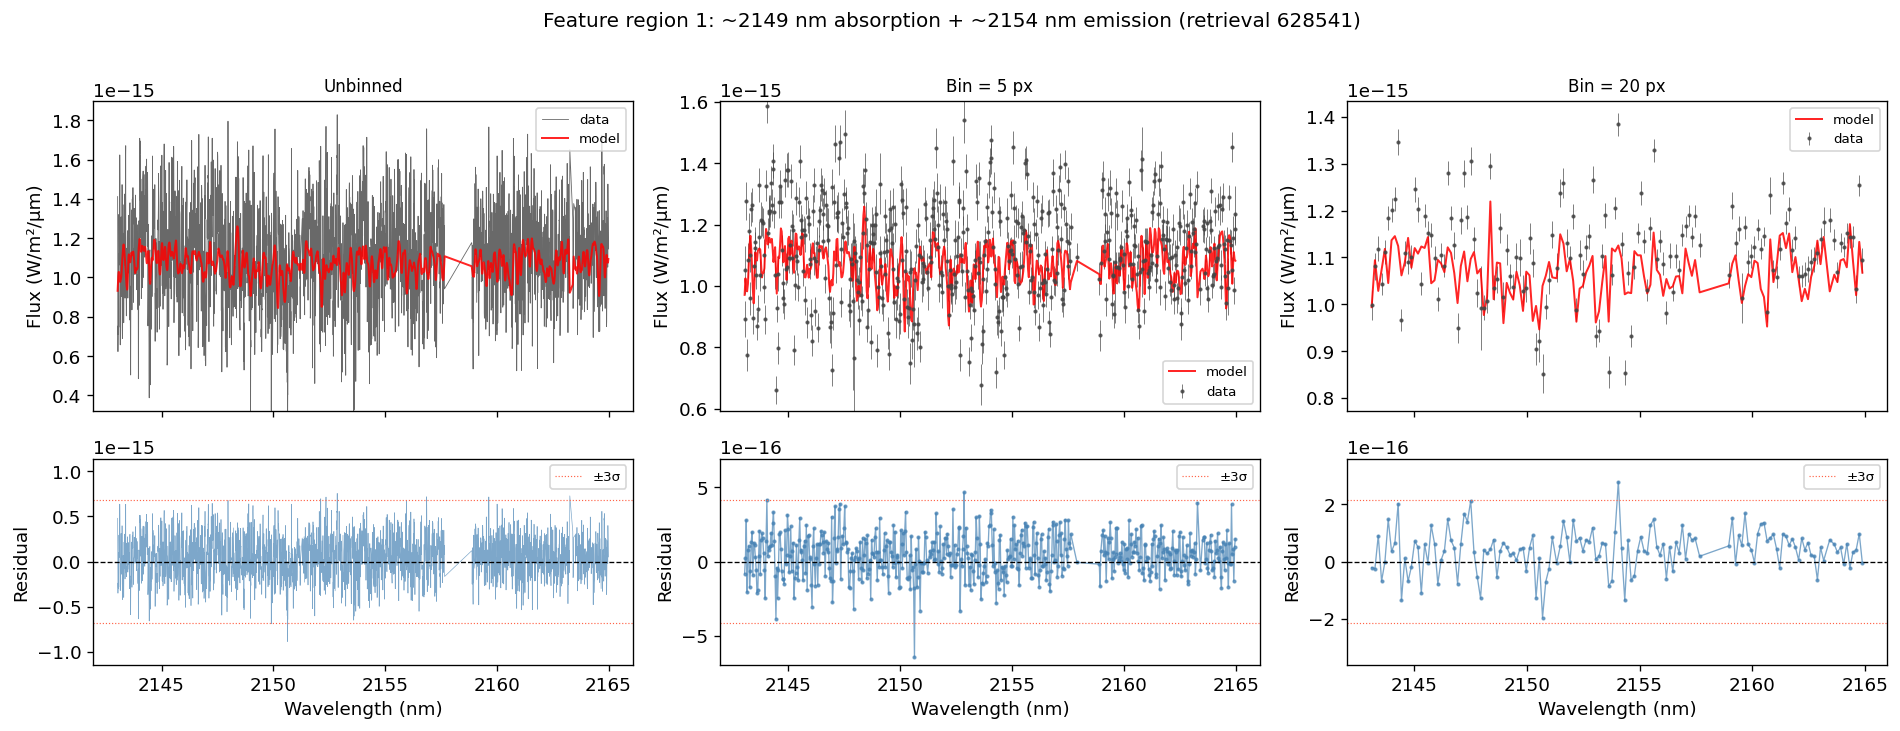

In [11]:
# Feature region 1: ~2149 nm absorption + ~2154 nm emission
fig1 = zoom_plot(
    wave_d, flux_d, err_d, wave_m, flux_m, valid_m,
    wmin=2140, wmax=2165,
    title='Feature region 1: ~2149 nm absorption + ~2154 nm emission (retrieval %s)' % RETRIEVAL_SERIES
)
fig1.savefig(RETRIEVAL_DIR / 'troubleshoot_zoom_2149_2154nm.png', dpi=200, bbox_inches='tight')
plt.show()

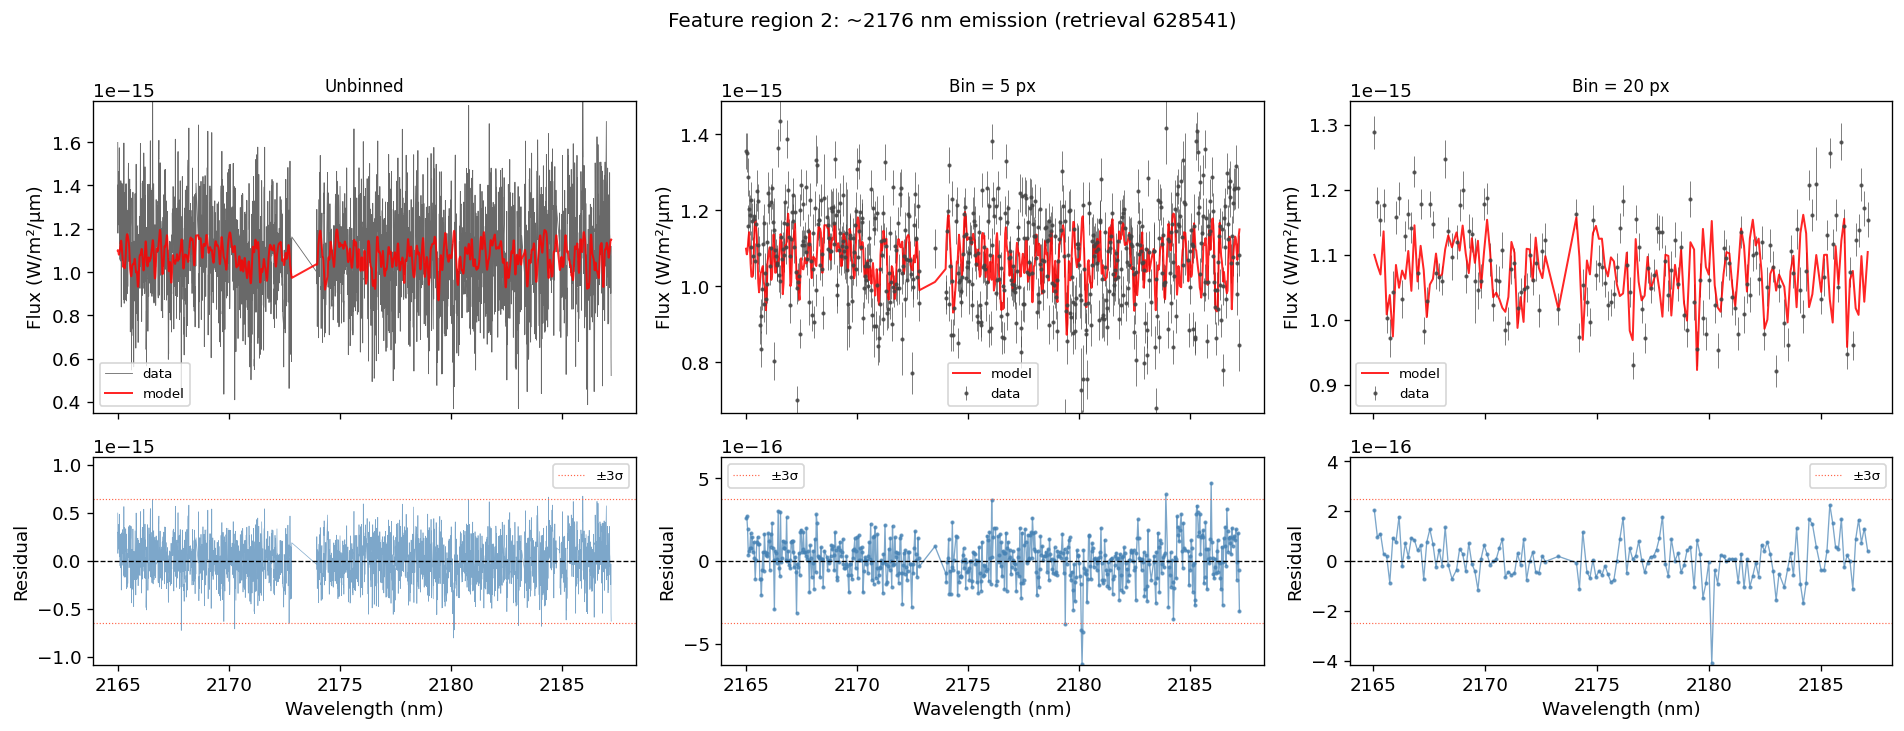

In [12]:
# Feature region 2: ~2176 nm emission
fig2 = zoom_plot(
    wave_d, flux_d, err_d, wave_m, flux_m, valid_m,
    wmin=2165, wmax=2190,
    title='Feature region 2: ~2176 nm emission (retrieval %s)' % RETRIEVAL_SERIES
)
fig2.savefig(RETRIEVAL_DIR / 'troubleshoot_zoom_2176nm.png', dpi=200, bbox_inches='tight')
plt.show()

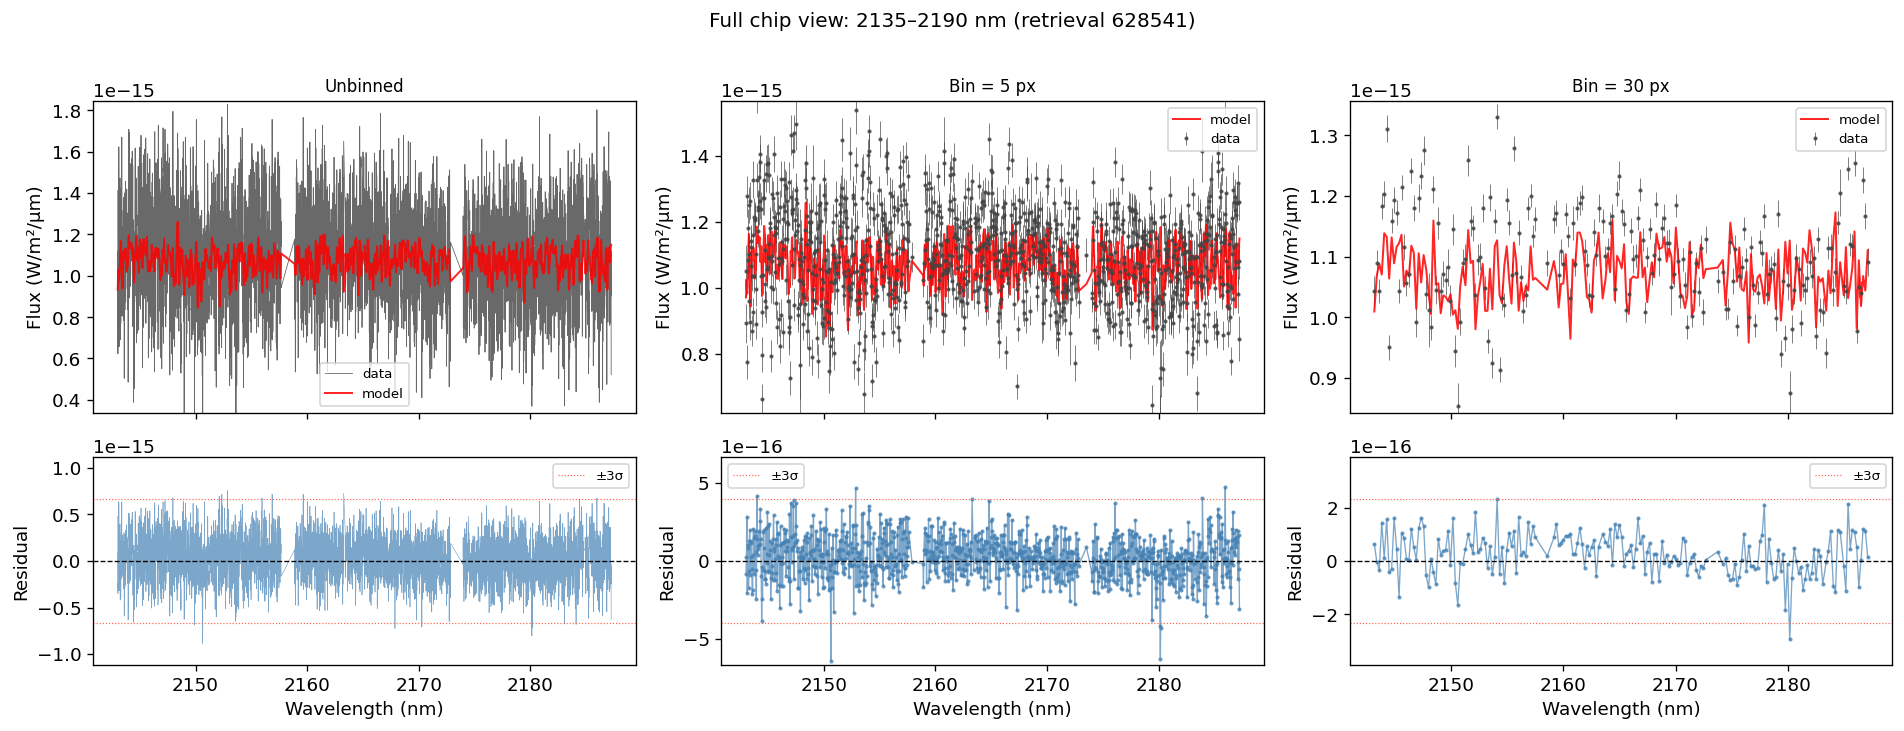

In [13]:
# Wide chip view covering all three features
fig3 = zoom_plot(
    wave_d, flux_d, err_d, wave_m, flux_m, valid_m,
    wmin=2135, wmax=2190,
    title='Full chip view: 2135–2190 nm (retrieval %s)' % RETRIEVAL_SERIES,
    bin_small=5, bin_large=30
)
fig3.savefig(RETRIEVAL_DIR / 'troubleshoot_zoom_full_chip_2135_2190nm.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Line depth diagnostics: are model lines systematically too shallow?

In [14]:
# Focus on 2100–2260 nm; use model flux as the reference continuum indicator
mask_roi = (wave_d >= 2100) & (wave_d <= 2260)
wd_roi = wave_d[mask_roi]
fd_roi = flux_d[mask_roi]
fm_roi = np.interp(wd_roi, wave_m[valid_m], flux_m[valid_m])
res_roi = fd_roi - fm_roi

# Continuum level: median of model in region
med_continuum = np.nanmedian(fm_roi)
in_line   = fm_roi < 0.95 * med_continuum  # model is in an absorption feature
continuum = fm_roi >= 0.95 * med_continuum

print('=== Residual statistics in 2100–2260 nm ===')
print(f'All pixels:        mean={np.nanmean(res_roi):.3e},  std={np.nanstd(res_roi):.3e}  (N={np.sum(np.isfinite(res_roi))})')
print(f'In absorption (<0.95×continuum):  mean={np.nanmean(res_roi[in_line]):.3e},  std={np.nanstd(res_roi[in_line]):.3e}  (N={in_line.sum()})')
print(f'Continuum (≥0.95×continuum):      mean={np.nanmean(res_roi[continuum]):.3e},  std={np.nanstd(res_roi[continuum]):.3e}  (N={continuum.sum()})')
print()
print('Positive mean in absorption → model lines too SHALLOW (data has deeper lines).')
print('Negative mean → model lines too DEEP.')

=== Residual statistics in 2100–2260 nm ===
All pixels:        mean=3.691e-17,  std=2.257e-16  (N=10809)
In absorption (<0.95×continuum):  mean=4.252e-17,  std=2.301e-16  (N=2475)
Continuum (≥0.95×continuum):      mean=3.525e-17,  std=2.244e-16  (N=8334)

Positive mean in absorption → model lines too SHALLOW (data has deeper lines).
Negative mean → model lines too DEEP.


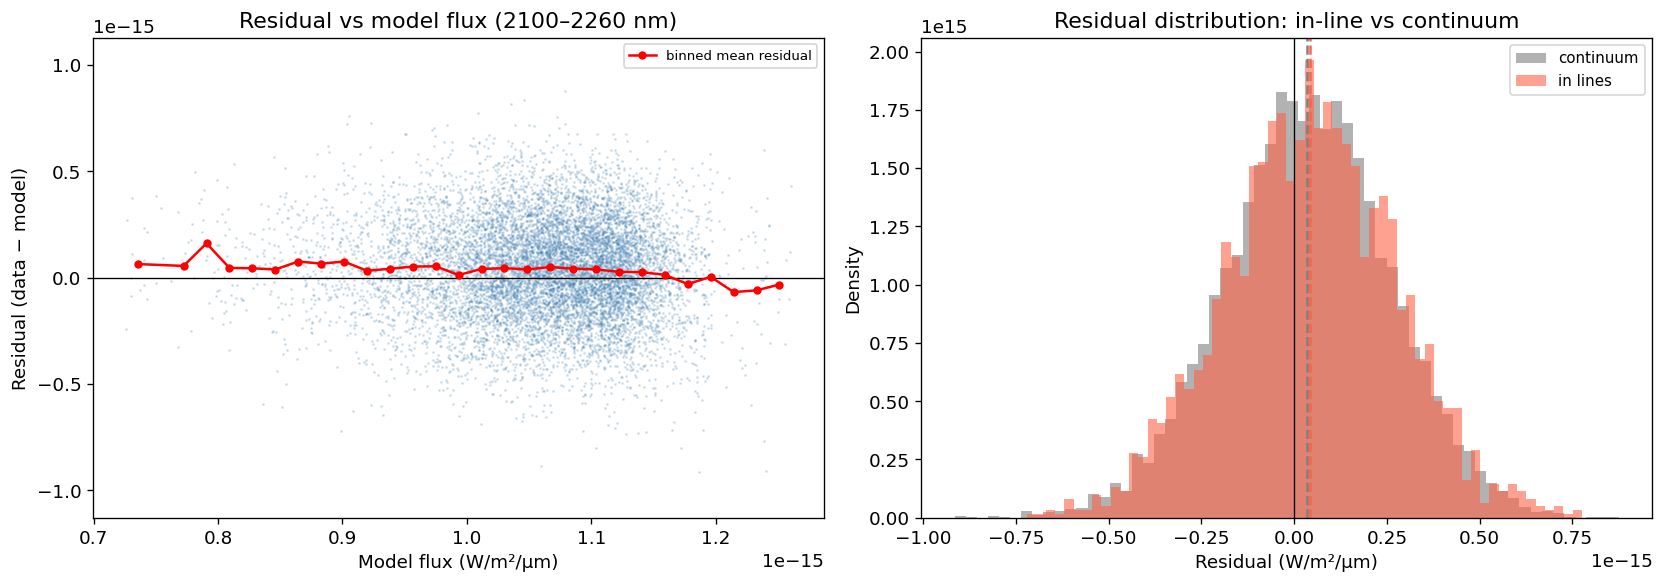

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual vs model flux — trend reveals systematic depth mismatch
ax = axes[0]
ax.scatter(fm_roi, res_roi, s=0.5, alpha=0.2, color='steelblue', rasterized=True)
ax.axhline(0, color='k', lw=0.8)
fm_bins = np.linspace(np.nanmin(fm_roi), np.nanmax(fm_roi), 30)
bin_means, bin_centers = [], []
for i in range(len(fm_bins)-1):
    sel = (fm_roi >= fm_bins[i]) & (fm_roi < fm_bins[i+1]) & np.isfinite(res_roi)
    if sel.sum() > 5:
        bin_centers.append(0.5*(fm_bins[i]+fm_bins[i+1]))
        bin_means.append(np.mean(res_roi[sel]))
ax.plot(bin_centers, bin_means, 'r-o', ms=4, lw=1.5, label='binned mean residual')
ax.set_xlabel('Model flux (W/m²/μm)')
ax.set_ylabel('Residual (data − model)')
ax.set_title('Residual vs model flux (2100–2260 nm)')
ax.legend(fontsize=8)
ax.set_ylim(-5*np.nanstd(res_roi), 5*np.nanstd(res_roi))

# Histogram: in-line vs continuum residuals
ax = axes[1]
kw = dict(bins=60, density=True, alpha=0.6, histtype='stepfilled')
ax.hist(res_roi[continuum & np.isfinite(res_roi)], color='gray',   label='continuum', **kw)
ax.hist(res_roi[in_line   & np.isfinite(res_roi)], color='tomato', label='in lines',  **kw)
ax.axvline(0, color='k', lw=0.8)
ax.axvline(np.nanmean(res_roi[in_line   & np.isfinite(res_roi)]), color='tomato', lw=1.5, ls='--')
ax.axvline(np.nanmean(res_roi[continuum & np.isfinite(res_roi)]), color='gray',   lw=1.5, ls='--')
ax.set_xlabel('Residual (W/m²/μm)')
ax.set_ylabel('Density')
ax.set_title('Residual distribution: in-line vs continuum')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RETRIEVAL_DIR / 'troubleshoot_line_depth_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Summary — interpretation guide

| Observation | Interpretation |
|---|---|
| Features vanish in unbinned + binned absolute-flux plot | → Hypothesis 1 confirmed: artifacts of high-pass filtering |
| Features persist in unbinned data but not model | → Real spectral features not captured by the model |
| Features persist in both unbinned and binned | → Likely real; investigate missing opacity or continuum |
| Mean residual in-line > 0 (positive) | → Model absorption lines systematically too shallow |
| Mean residual in-line ≈ 0 | → Line depths OK on average |

**Next steps if features are real**:
- Identify the molecular/atomic carrier at 2149, 2154, 2176 nm
- Check if wavelengths coincide with known H₂O, CO, CH₄ lines or Brγ emission (2166 nm)
- Check telluric correction quality at those wavelengths

**Next steps if model lines are systematically shallow**:
- Check abundance posteriors (C/O, [C/H]) — may be underestimated
- Inspect P-T profile in the line-forming region
- Check broadening parameters (vsini, R)